# (26) poisson + Kyoto16: (16, 32.0)

project = ```iP-VAE```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Trainer

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'Kyoto16')

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 48.0

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

poisson_Kyoto16_t-16_z-[512]_cl-10,10_<grad|lin>
b200-ep600-lr(0.002)_beta(48:0.1)_temp(0.01:0.5)_gr(500)_(2025_02_26,22:42)

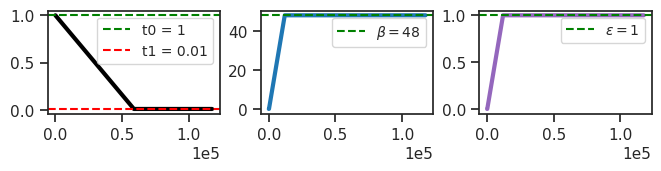

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
print(tr.model.layer)
print(tr.model.layer.n_exp)

PoissonLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [6]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:1', grad_fn=<ExpBackward0>),)

In [7]:
tr.train()

epoch # 600, avg loss: 304.681928: 100%|████| 600/600 [2:29:22<00:00, 14.94s/it]


In [7]:
### Was: Kyoto16, (16, 16.0)

epoch # 600, avg loss: 257.634760: 100%|████| 600/600 [2:33:09<00:00, 15.32s/it]


In [8]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.1158], device='cuda:1', grad_fn=<ExpBackward0>),)

In [9]:
print(tr.model.layer.n_exp)

tensor([10, 11, 13, 15, 16, 18, 21, 23, 26, 29, 31, 31, 32, 33, 33, 34],
       device='cuda:1', dtype=torch.int32)

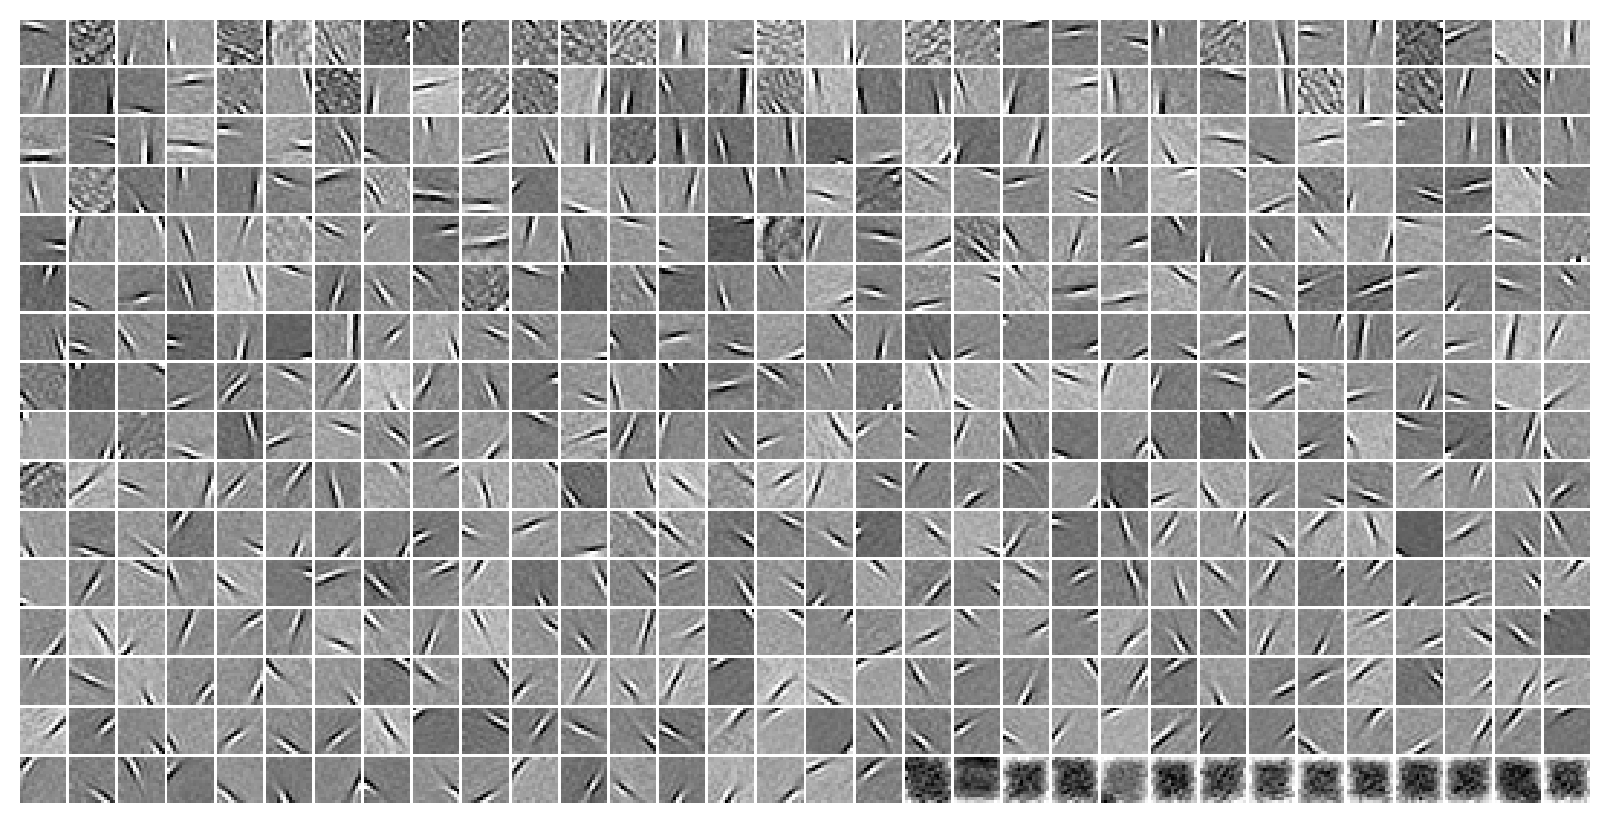

In [10]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

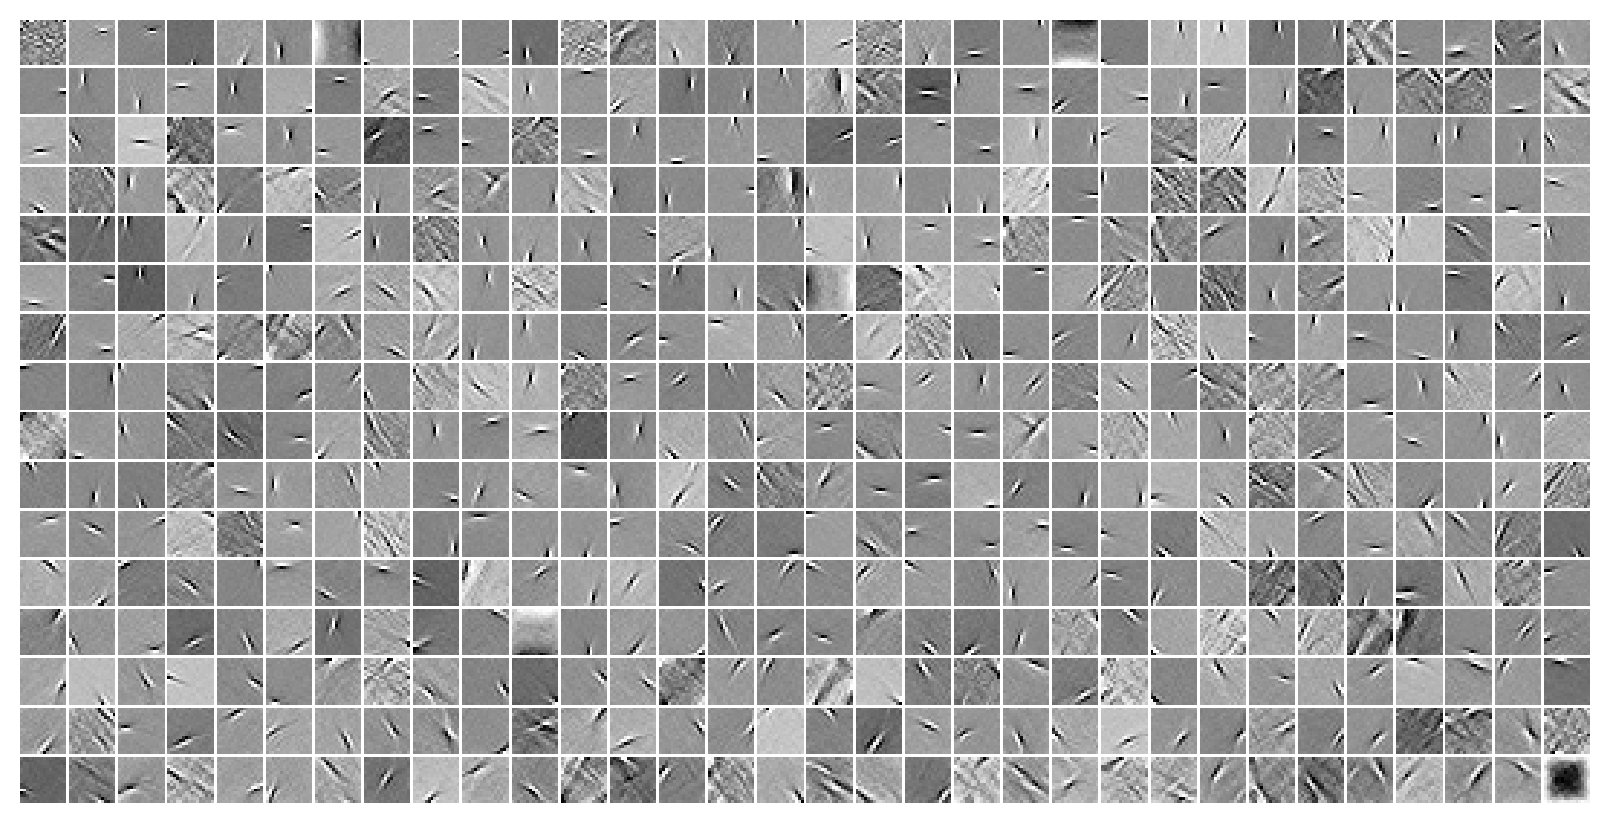

In [10]:
### Was: Kyoto16, (16, 12.0)

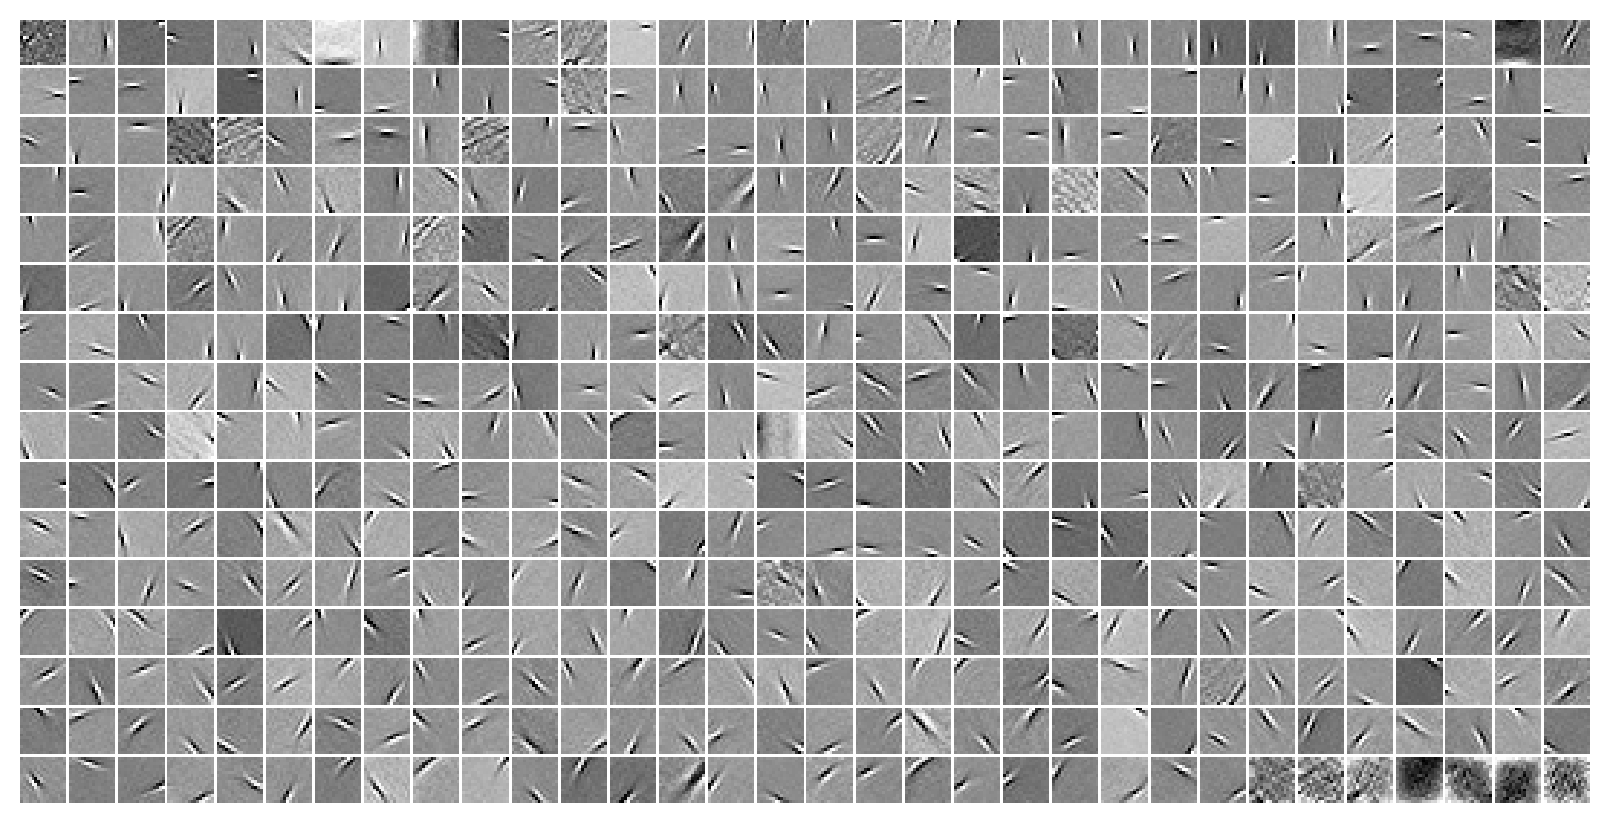

In [10]:
### Was: Kyoto16, (16, 24.0)

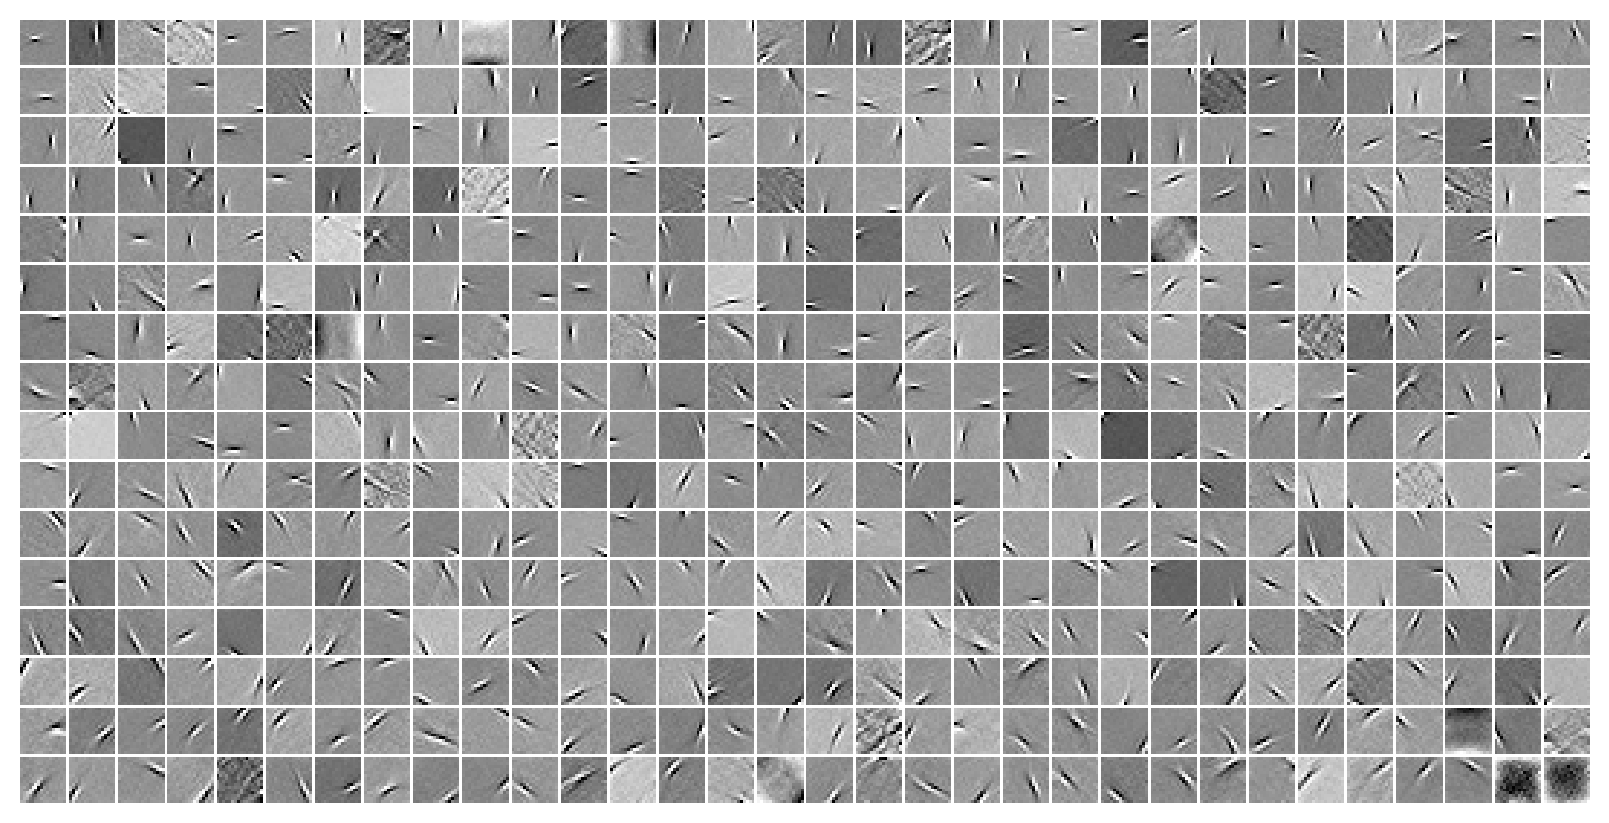

In [10]:
### Was: Kyoto16, (16, 16.0)

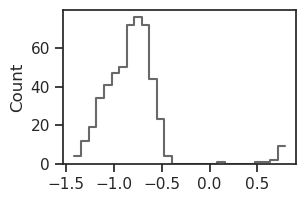

In [11]:
histplot(u0, color='dimgrey');

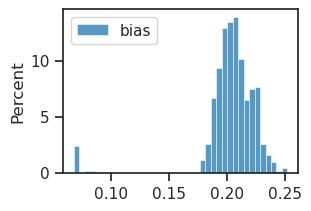

In [12]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

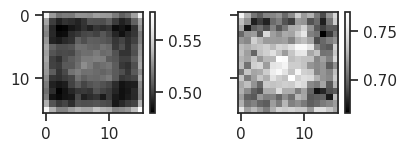

In [13]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [01:00<00:00, 30.31s/it]


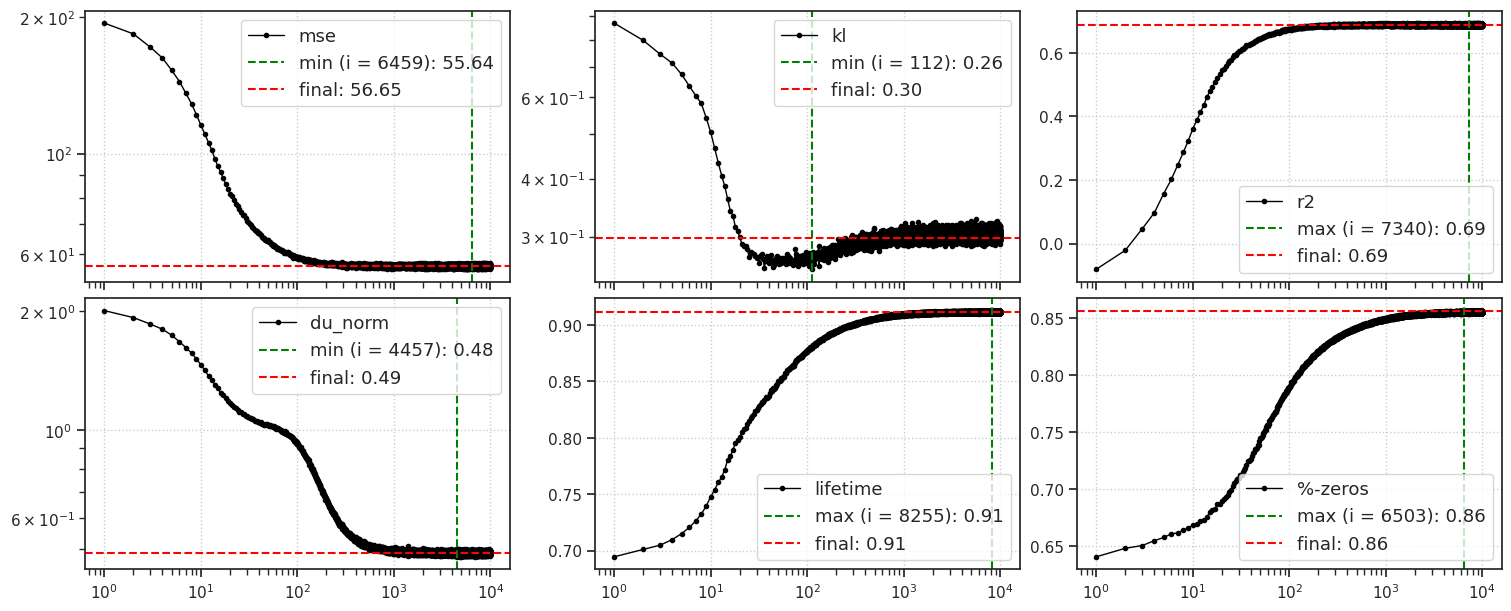

CPU times: user 1min 10s, sys: 6.43 s, total: 1min 17s
Wall time: 1min 17s


In [14]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

100%|███████████████████████████████████| 2/2 [00:59<00:00, 29.82s/it]


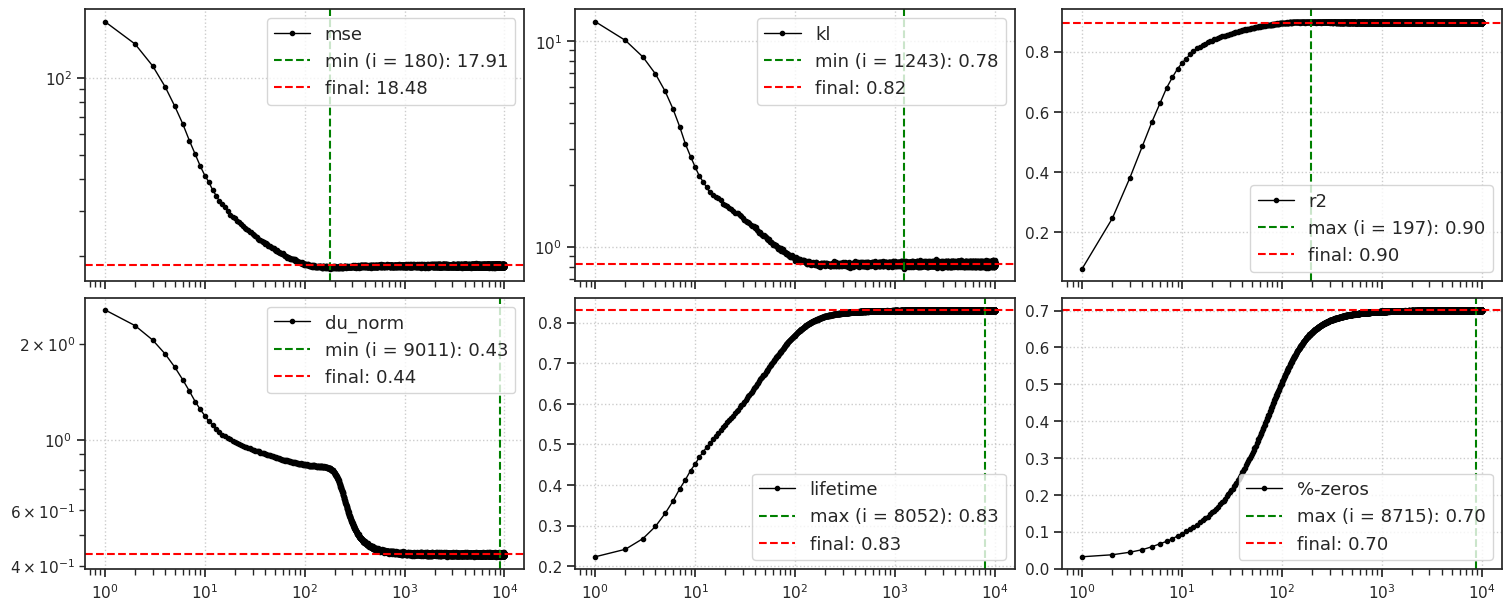

CPU times: user 1min 10s, sys: 5.92 s, total: 1min 16s
Wall time: 1min 16s


In [14]:
### Was: Kyoto16, (16, 12.0)

100%|███████████████████████████████████| 2/2 [01:08<00:00, 34.45s/it]


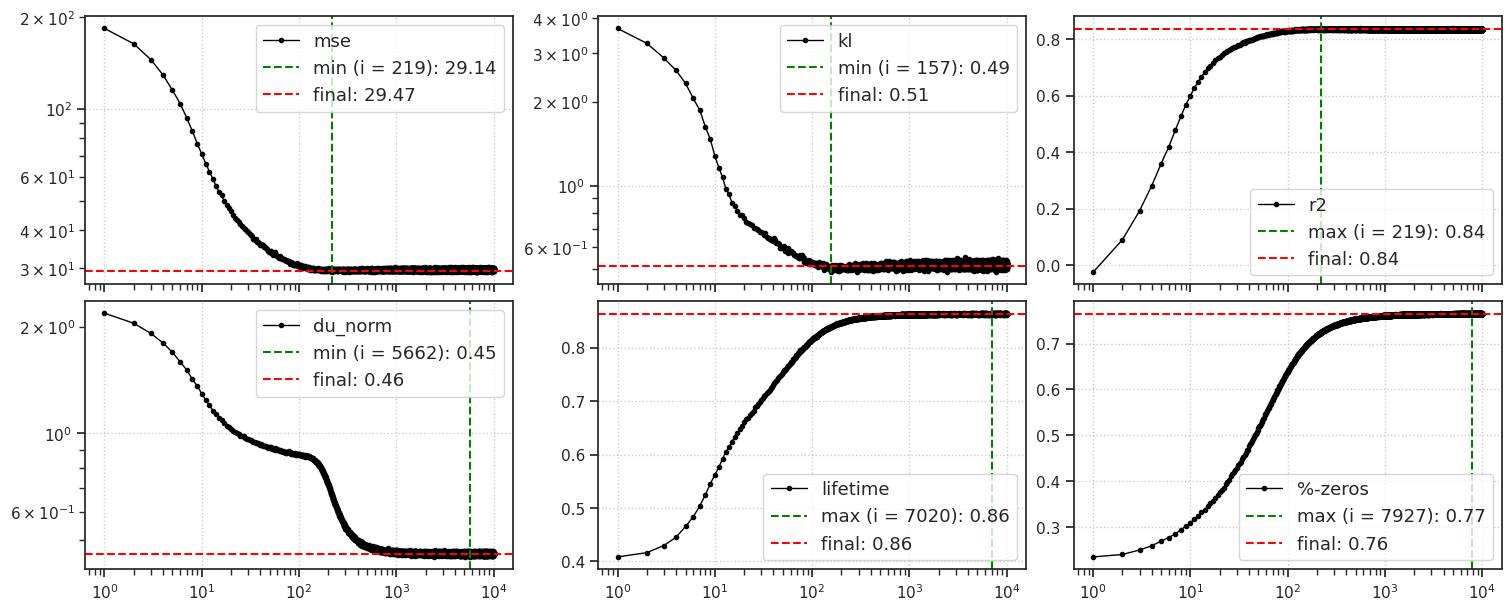

CPU times: user 1min 20s, sys: 6.05 s, total: 1min 26s
Wall time: 1min 26s


In [16]:
### Was: Kyoto16, (16, 24.0)

100%|███████████████████████████████████| 2/2 [01:02<00:00, 31.45s/it]


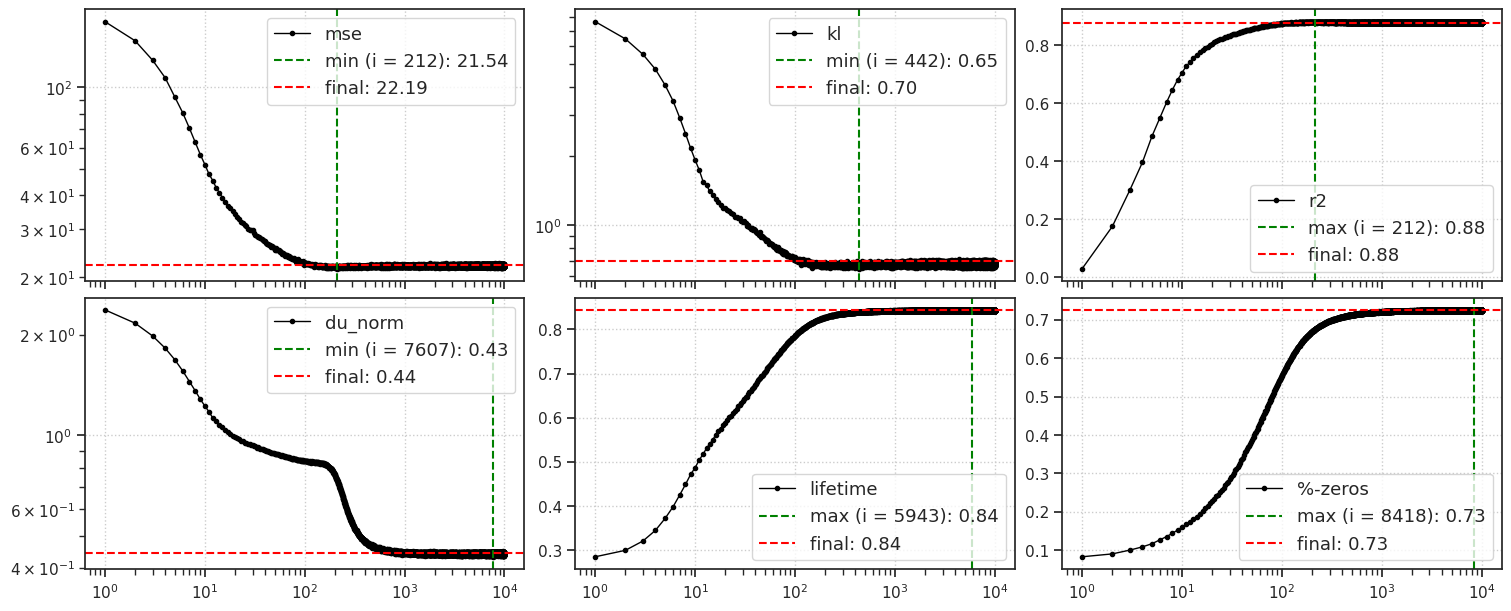

CPU times: user 1min 13s, sys: 5.97 s, total: 1min 19s
Wall time: 1min 19s


In [15]:
### Was: Kyoto16, (16, 16.0)

100%|███████████████████████████████████| 2/2 [00:42<00:00, 21.37s/it]


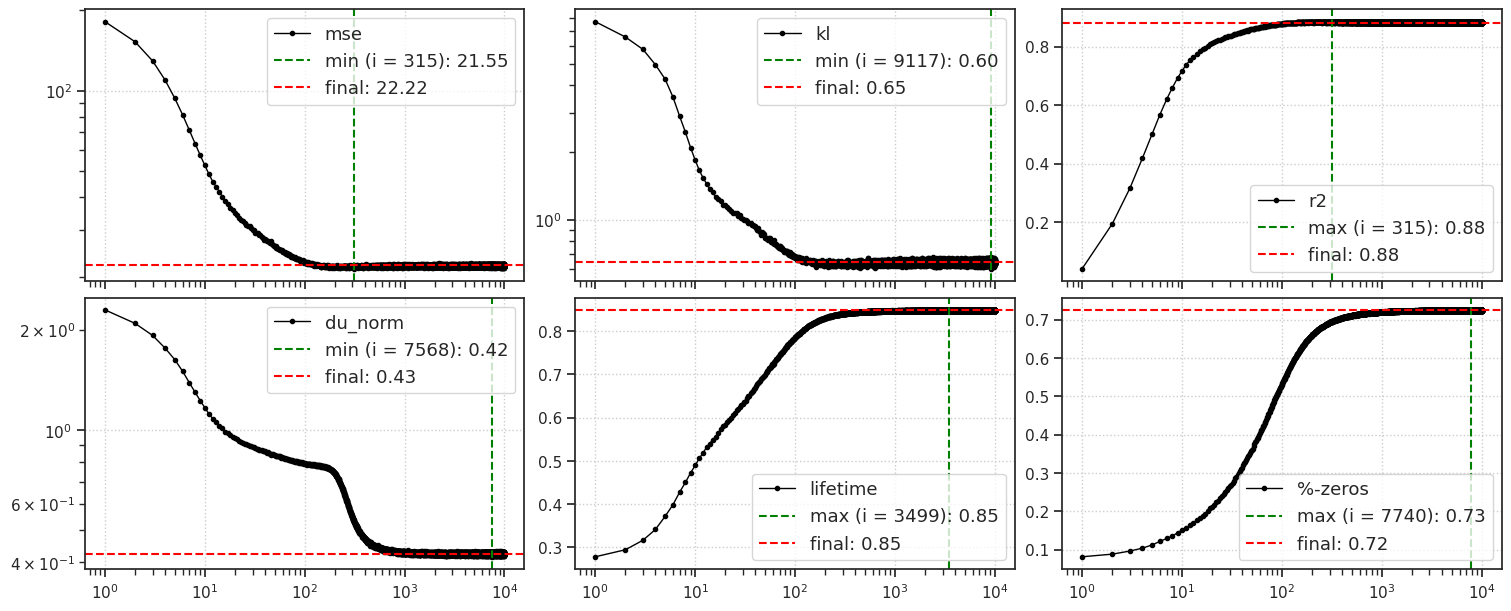

CPU times: user 51.3 s, sys: 2.58 s, total: 53.9 s
Wall time: 53.9 s


In [16]:
## vH16: (16, 16.0)

100%|███████████████████████████████████| 2/2 [00:41<00:00, 20.82s/it]


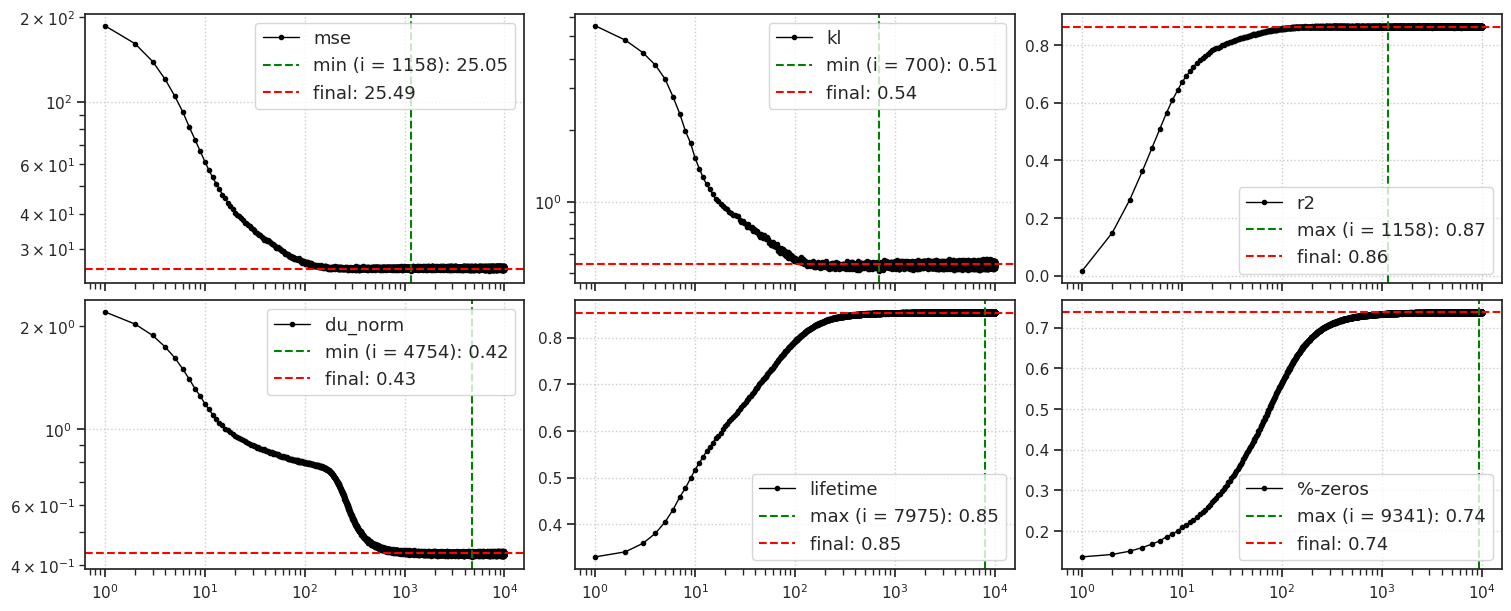

CPU times: user 50 s, sys: 2.79 s, total: 52.8 s
Wall time: 52.8 s


In [15]:
### Was: beta = 20.0

## output

In [16]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

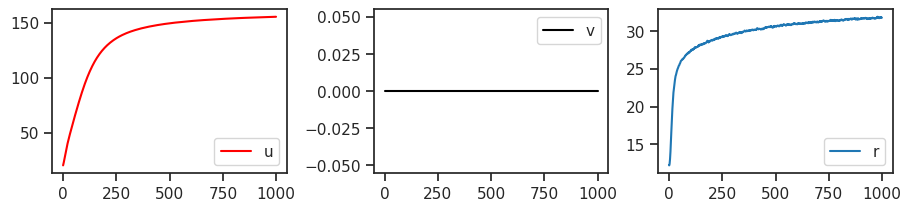

In [17]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

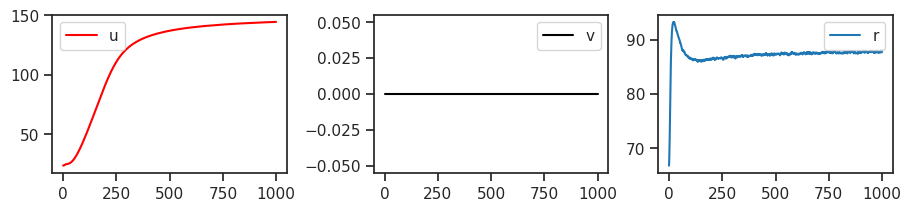

In [19]:
### Was: Kyoto16, (16, 16.0)

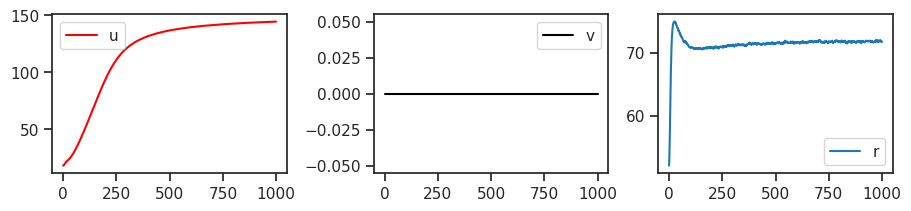

In [17]:
### Was: beta = 20.0

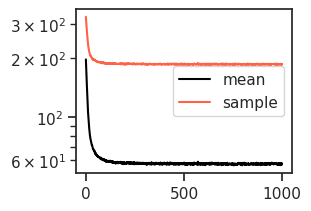

(tensor([57.3211, 57.5915, 57.5813, 56.8984, 57.6914], device='cuda:1'),
 tensor([185.8176, 187.2444, 186.9391, 185.7888, 187.2117], device='cuda:1'))

In [18]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)

samples = torch.stack([
    p.sample() for p in
    output['conditional'].values()
], dim=1)

mse_locs = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
mse_samples = (samples - feeder[0].unsqueeze(1)).pow(2).sum(-1)

fig, ax = create_figure()
ax.plot(tonp(mse_locs.mean(0)), color='k', label='mean')
ax.plot(tonp(mse_samples.mean(0)), color='tomato', label='sample')
ax.set_yscale('log')
add_legend(ax)
plt.show()

mse_locs.mean(0)[-5:], mse_samples.mean(0)[-5:]

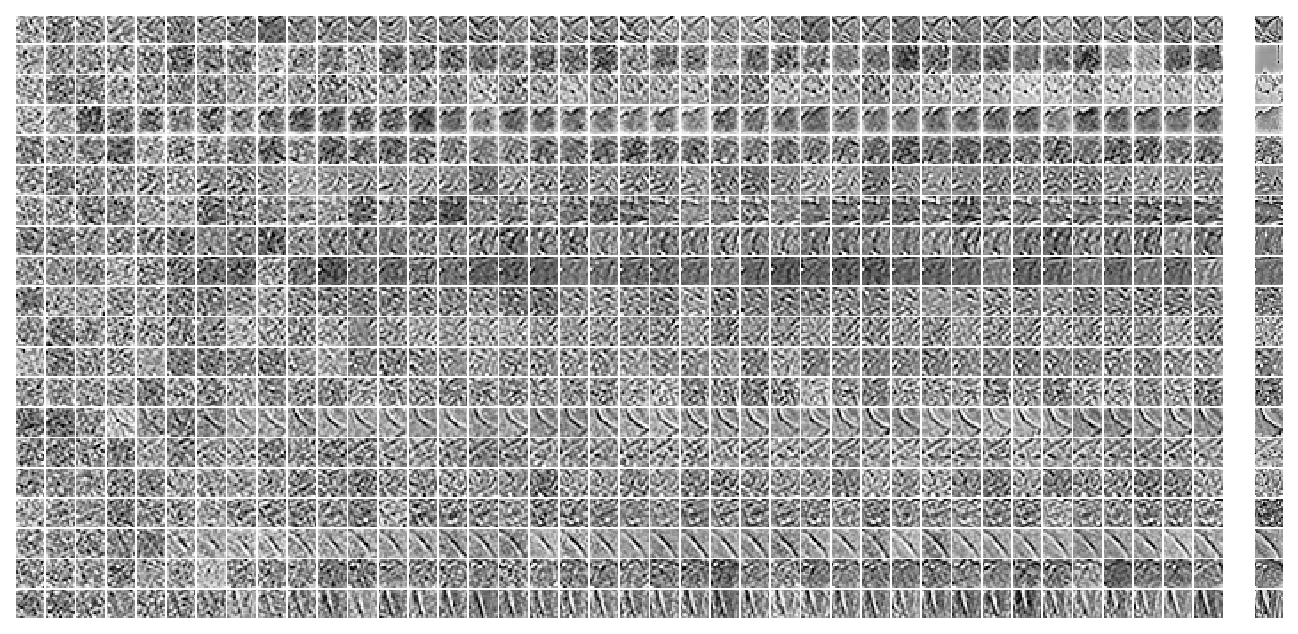

In [21]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

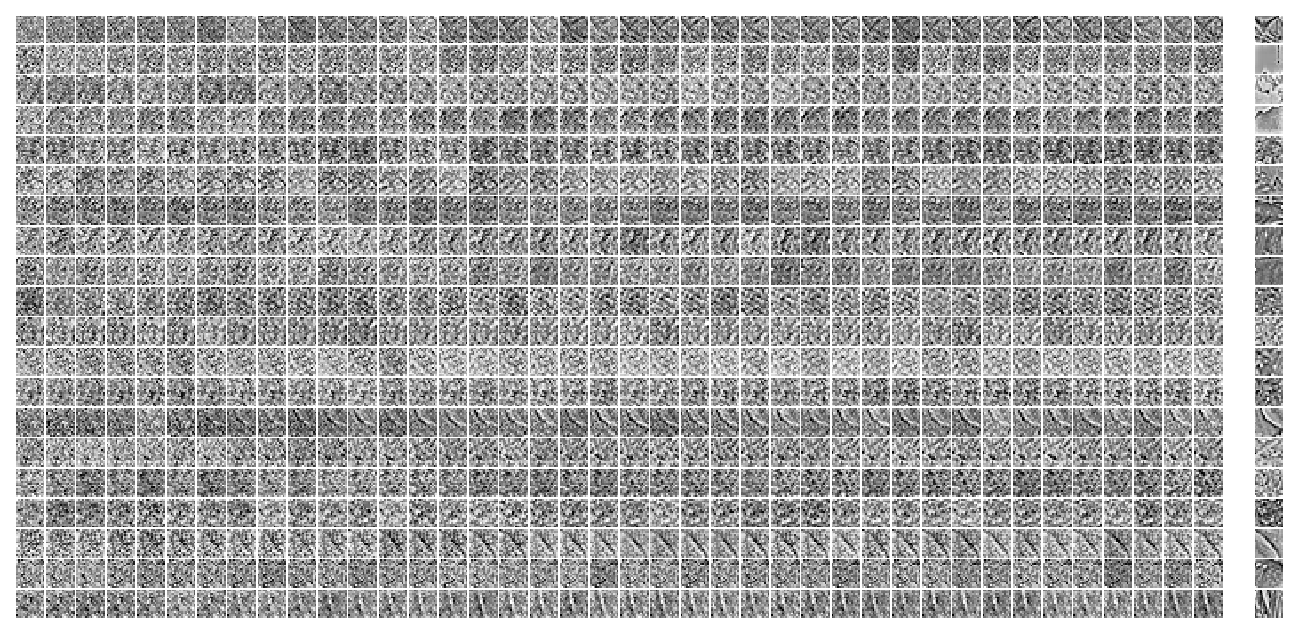

In [22]:
x2p = tonp(samples)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)